In [42]:
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [43]:
data_train = pd.read_csv("train.csv")
data_train.head()

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,VID_18655,40,1031602,8523,363,1095,2016-09-14,PT7M37S,F
1,VID_14135,2,1707,56,2,6,2016-10-01,PT9M30S,D
2,VID_2187,1,2023,25,0,2,2016-07-02,PT2M16S,C
3,VID_23096,6,620860,777,161,153,2016-07-27,PT4M22S,H
4,VID_10175,1,666,1,0,0,2016-06-29,PT31S,D


In [44]:
data_train.shape

(14999, 9)

In [45]:
data_train.dtypes

vidid        object
adview        int64
views        object
likes        object
dislikes     object
comment      object
published    object
duration     object
category     object
dtype: object

In [46]:
# Assigning each category a number for Category feature

category={'A': 1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7,'H':8}
data_train["category"]=data_train["category"].map(category)
data_train.head()

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,VID_18655,40,1031602,8523,363,1095,2016-09-14,PT7M37S,6
1,VID_14135,2,1707,56,2,6,2016-10-01,PT9M30S,4
2,VID_2187,1,2023,25,0,2,2016-07-02,PT2M16S,3
3,VID_23096,6,620860,777,161,153,2016-07-27,PT4M22S,8
4,VID_10175,1,666,1,0,0,2016-06-29,PT31S,4


# Clean the dataset by removing missing values and other things.


In [47]:
# Removing character "F" present in data
data_train=data_train[data_train.views!='F']
data_train=data_train[data_train.likes!='F']
data_train=data_train[data_train.dislikes!='F']
data_train=data_train[data_train.comment!='F']
data_train.head()


,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,VID_18655,40,1031602,8523,363,1095,2016-09-14,PT7M37S,6
1,VID_14135,2,1707,56,2,6,2016-10-01,PT9M30S,4
2,VID_2187,1,2023,25,0,2,2016-07-02,PT2M16S,3
3,VID_23096,6,620860,777,161,153,2016-07-27,PT4M22S,8
4,VID_10175,1,666,1,0,0,2016-06-29,PT31S,4


In [48]:
data_train.shape

(14637, 9)

In [49]:
data_train.dtypes

vidid        object
adview        int64
views        object
likes        object
dislikes     object
comment      object
published    object
duration     object
category      int64
dtype: object

#Transform attributes into numerical values and other necessary transformations

In [50]:
# Convert values to integers for views, likes, comments, dislikes and adview
data_train["views"] = pd.to_numeric(data_train["views"])
data_train["comment"] = pd.to_numeric(data_train["comment"])
data_train["likes"] = pd.to_numeric(data_train["likes"])
data_train["dislikes"] = pd.to_numeric(data_train["dislikes"])
data_train["adview"]=pd.to_numeric(data_train["adview"])



In [51]:
column_vidid=data_train['vidid']

In [52]:
# Endoding features like  Published, Vidid
from sklearn.preprocessing import LabelEncoder
data_train['vidid']=LabelEncoder().fit_transform(data_train['vidid'])
data_train['published']=LabelEncoder().fit_transform(data_train['published'])
data_train.head()


,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,5912,40,1031602,8523,363,1095,2168,PT7M37S,6
1,2741,2,1707,56,2,6,2185,PT9M30S,4
2,8138,1,2023,25,0,2,2094,PT2M16S,3
3,9005,6,620860,777,161,153,2119,PT4M22S,8
4,122,1,666,1,0,0,2091,PT31S,4


In [53]:
# Convert Time_in_sec for duration
import datetime
import time

def checki(x):
  y = x[2:]
  h = ''
  m = ''
  s = ''
  mm = ''
  P = ['H','M','S']
  for i in y:
    if i not in P:
      mm+=i
    else:
      if(i=="H"):
        h = mm
        mm = ''
      elif(i == "M"):
        m = mm
        mm = ''
      else:
        s = mm
        mm = ''
  if(h==''):
    h = '00'
  if(m == ''):
    m = '00'
  if(s==''):
    s='00'
  bp = h+':'+m+':'+s
  return bp
train=pd.read_csv("train.csv")
mp = pd.read_csv("train.csv")["duration"]
time = mp.apply(checki)
def func_sec(time_string):
  h, m, s = time_string.split(':')
  return int(h) * 3600 + int(m) * 60 + int(s)
time1=time.apply(func_sec)
data_train["duration"]=time1
data_train.head()

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,5912,40,1031602,8523,363,1095,2168,457,6
1,2741,2,1707,56,2,6,2185,570,4
2,8138,1,2023,25,0,2,2094,136,3
3,9005,6,620860,777,161,153,2119,262,8
4,122,1,666,1,0,0,2091,31,4


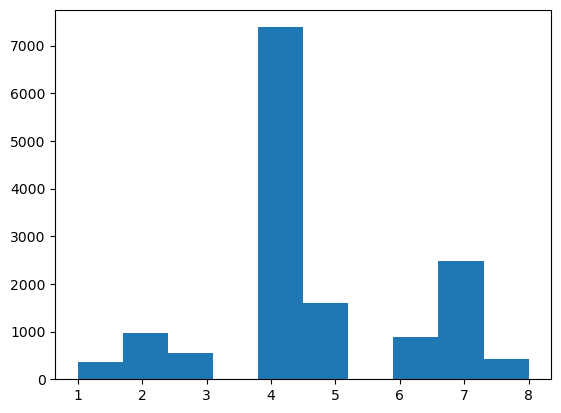

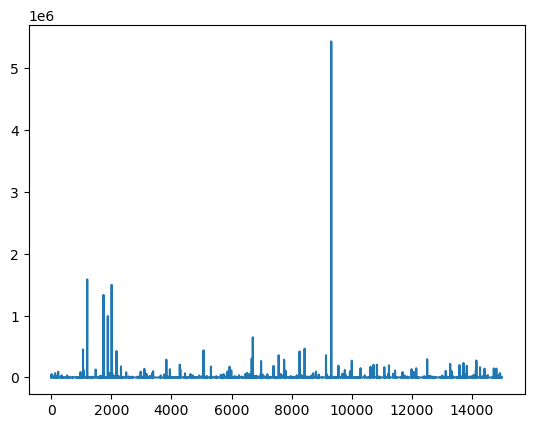

In [54]:
# Visualization
# Individual Plots
plt.hist(data_train["category"])
plt.show()
plt.plot(data_train["adview"])
plt.show()
# Remove videos with adview greater than 2000000 as outlier
data_train = data_train[data_train["adview"] <1000000]


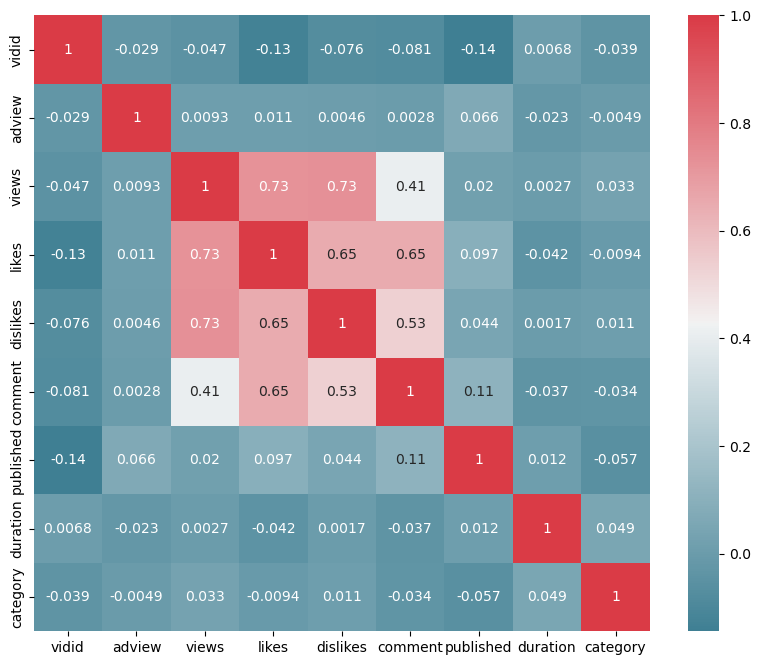

In [55]:
# Heatmap
import seaborn as sns
f, ax = plt.subplots(figsize=(10, 8))
corr = data_train.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool_), cmap=sns.diverging_palette(220, 10, as_cmap=True),
square=True, ax=ax, annot=True)
plt.show()

#5. Normalise your data and split the data into training, validation and test set in the appropriate ratio.

In [56]:
# Split Data
Y_train = pd.DataFrame(data = data_train.iloc[:, 1].values, columns = ['target'])
data_train=data_train.drop(["adview"],axis=1)
data_train=data_train.drop(["vidid"],axis=1)
data_train.head()



,views,likes,dislikes,comment,published,duration,category
0,1031602,8523,363,1095,2168,457,6
1,1707,56,2,6,2185,570,4
2,2023,25,0,2,2094,136,3
3,620860,777,161,153,2119,262,8
4,666,1,0,0,2091,31,4


In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data_train, Y_train, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(11706, 7)
(2927, 7)
(11706, 1)
(2927, 1)


In [58]:
# Normalise Data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)
X_train.mean()

0.17340469663005678

#6. Use linear regression, support vector regressor, random forest and for training and get errors.


In [59]:
from sklearn import metrics
def print_error(X_test, y_test, model_name):
  prediction = model_name.predict(X_test)
  print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, prediction))
  print('Mean Squared Error:', metrics.mean_squared_error(y_test, prediction))
  print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, prediction)))


In [60]:
# Linear Regression
from sklearn import linear_model
linear_regression = linear_model.LinearRegression()
linear_regression.fit(X_train, y_train)
print_error(X_test,y_test, linear_regression)


Mean Absolute Error: 3048.350025889562
Mean Squared Error: 333520646.5816719
Root Mean Squared Error: 18262.54764762222


In [61]:
# Support Vector Regressor
from sklearn.svm import SVR
supportvector_regressor = SVR()
supportvector_regressor.fit(X_train,y_train.values.ravel())
print_error(X_test,y_test, linear_regression)


Mean Absolute Error: 3048.350025889562
Mean Squared Error: 333520646.5816719
Root Mean Squared Error: 18262.54764762222


#7. Use Decision Tree Regressor and Random Forest Regressors.


In [62]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
decision_tree = DecisionTreeRegressor()
decision_tree.fit(X_train, y_train)
print_error(X_test,y_test, decision_tree)


Mean Absolute Error: 3121.756747523061
Mean Squared Error: 956148941.3809361
Root Mean Squared Error: 30921.658127935767


In [63]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
n_estimators = 200
max_depth = 20
min_samples_split=15
min_samples_leaf=2
random_forest = RandomForestRegressor(n_estimators = n_estimators, max_depth = max_depth, min_samples_split=min_samples_split)
random_forest.fit(X_train,y_train.values.ravel())
print_error(X_test,y_test, random_forest)

Mean Absolute Error: 2800.8955300112893
Mean Squared Error: 309863681.9660663
Root Mean Squared Error: 17602.945263962683


#8. Build an artificial neural network and train it with different layers and hyperparameters. 

In [64]:
# Artificial Neural Network
import keras
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping

# Artificial Neural Network
ann = keras.models.Sequential([
    Input(shape=X_train.shape[1:]),  # Use Input layer instead of input_shape in Dense layer
    Dense(6, activation="relu"),
    Dense(6, activation="relu"),
    Dense(1)
])

# Optimizer and Loss
optimizer = keras.optimizers.Adam()
loss = keras.losses.mean_squared_error

# Compile the model
ann.compile(optimizer=optimizer, loss=loss, metrics=["mean_squared_error"])

# Early Stopping Callback
early_stopping = EarlyStopping(
    monitor="val_loss",         # Monitor the validation loss
    patience=10,                # Stop if val_loss doesn't improve for 10 consecutive epochs
    restore_best_weights=True   # Restore the weights of the best epoch
)

# Train the model with Early Stopping
history = ann.fit(
    X_train, y_train,
    validation_split=0.2,  # Use 20% of the training data for validation
    epochs=100,
    callbacks=[early_stopping]
)

# Model Summary
ann.summary()

# Assuming `print_error` is defined elsewhere
print_error(X_test, y_test, ann)


Epoch 1/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 212417888.0000 - mean_squared_error: 212417888.0000 - val_loss: 117927640.0000 - val_mean_squared_error: 117927640.0000
Epoch 2/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 219611168.0000 - mean_squared_error: 219611168.0000 - val_loss: 117920968.0000 - val_mean_squared_error: 117920968.0000
Epoch 3/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 297374144.0000 - mean_squared_error: 297374144.0000 - val_loss: 117903096.0000 - val_mean_squared_error: 117903096.0000
Epoch 4/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 410739296.0000 - mean_squared_error: 410739296.0000 - val_loss: 117870216.0000 - val_mean_squared_error: 117870216.0000
Epoch 5/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 525040512.0000 - mean_squared_error: 525040512.0000 - val_loss: 117823992.0000 - val_mean_squared_error: 117823992.0000
Epoch 6/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 646709952.0000 - mean_squar

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 6)                   │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │              42 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               7 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 293 (1.15 KB)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 196 (788.00 B)

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Mean Absolute Error: 2555.259933529024
Mean Squared Error: 335074838.3276733
Root Mean Squared Error: 18305.049530871893


#10. Save your model and predict on test set.

In [65]:
#Saving Scikitlearn models
import joblib
joblib.dump(decision_tree, "decisiontree_youtubeadview.pkl")
# Saving Keras Artificial Neural Network model
ann.save("ann_youtubeadview.keras")

In [66]:
import joblib
classifer = joblib.load("decisiontree_youtubeadview.pkl")

In [67]:
prediction = classifer.predict(X_test)
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, prediction))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, prediction))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, prediction)))

Mean Absolute Error: 3121.756747523061
Mean Squared Error: 956148941.3809361
Root Mean Squared Error: 30921.658127935767


# **Youtube adview Prediction Project** 


> Test_Data using test.csv




In [68]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm

In [69]:
#loading the data
df = pd.read_csv('test.csv');
df.head()

,vidid,views,likes,dislikes,comment,published,duration,category
0,VID_1054,440238,6153,218,1377,2017-02-18,PT7M29S,B
1,VID_18629,1040132,8171,340,1047,2016-06-28,PT6M29S,F
2,VID_13967,28534,31,11,1,2014-03-10,PT37M54S,D
3,VID_19442,1316715,2284,250,274,2010-06-05,PT9M55S,G
4,VID_770,1893173,2519,225,116,2016-09-03,PT3M8S,B


In [70]:
#mapping category feature to numbers
category = {'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7,'H':8}

#transforming category
df['category'] = df['category'].map(category)
df.head()

,vidid,views,likes,dislikes,comment,published,duration,category
0,VID_1054,440238,6153,218,1377,2017-02-18,PT7M29S,2
1,VID_18629,1040132,8171,340,1047,2016-06-28,PT6M29S,6
2,VID_13967,28534,31,11,1,2014-03-10,PT37M54S,4
3,VID_19442,1316715,2284,250,274,2010-06-05,PT9M55S,7
4,VID_770,1893173,2519,225,116,2016-09-03,PT3M8S,2


In [71]:
df.shape

(8764, 8)

In [72]:
# removing F from likes, dislikes, views, comments and adviews
df = df[df.views != 'F']
df = df[df.comment != 'F']
df = df[df.dislikes != 'F']
df = df[df.likes != 'F']

In [73]:
#rows with F in views, likes, dislikes and comment is removed
df.shape

(8549, 8)

In [74]:
df.dtypes
# as we can see likes, views etc has object dtypes. So, need to covert to numeric

vidid        object
views        object
likes        object
dislikes     object
comment      object
published    object
duration     object
category      int64
dtype: object

In [75]:
df['views'] = pd.to_numeric(df['views'])
df['comment'] = pd.to_numeric(df['comment'])
df['likes'] = pd.to_numeric(df['likes'])
df['dislikes'] = pd.to_numeric(df['dislikes'])

In [76]:
# storing vidid column in another variable for further use
col_vidid = df['vidid']

In [77]:
# performing encoding on vivid, duration and published
from sklearn.preprocessing import LabelEncoder
df['published'] = LabelEncoder().fit_transform(df['published'])
df['vidid'] = LabelEncoder().fit_transform(df['vidid'])
df['duration'] = LabelEncoder().fit_transform(df['duration'])
df.head()

,vidid,views,likes,dislikes,comment,published,duration,category
0,231,440238,6153,218,1377,2053,2115,2
1,3444,1040132,8171,340,1047,1825,2055,6
2,1593,28534,31,11,1,1009,1506,4
3,3775,1316715,2284,250,274,116,2265,7
4,7644,1893173,2519,225,116,1892,1625,2


In [78]:
# Convert Time_in_sec for duration
import datetime
import time
def checki(x):
  y = x[2:]
  h = ''
  m = ''
  s = ''
  mm = ''
  P = ['H','M','S']
  for i in y:
    if i not in P:
      mm+=i
    else:
      if(i=="H"):
        h = mm
        mm = ''
      elif(i == "M"):
        m = mm
        mm = ''
      else:
        s = mm
        mm = ''
  if(h==''):
    h = '00'
  if(m == ''):
    m = '00'
  if(s==''):
    s='00'
  bp = h+':'+m+':'+s
  return bp
train=pd.read_csv("test.csv")
mp = pd.read_csv("test.csv")["duration"]
time = mp.apply(checki)

def func_sec(time_string):
  h, m, s = time_string.split(':')
  return int(h) * 3600 + int(m) * 60 + int(s)

time1=time.apply(func_sec)

df["duration"]=time1
df.head()

,vidid,views,likes,dislikes,comment,published,duration,category
0,231,440238,6153,218,1377,2053,449,2
1,3444,1040132,8171,340,1047,1825,389,6
2,1593,28534,31,11,1,1009,2274,4
3,3775,1316715,2284,250,274,116,595,7
4,7644,1893173,2519,225,116,1892,188,2


In [79]:
df = df.drop(['vidid'],axis=1)
df.head()

,views,likes,dislikes,comment,published,duration,category
0,440238,6153,218,1377,2053,449,2
1,1040132,8171,340,1047,1825,389,6
2,28534,31,11,1,1009,2274,4
3,1316715,2284,250,274,116,595,7
4,1893173,2519,225,116,1892,188,2


In [90]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
array =df.to_numpy();
prediction = random_forest.predict(array)

In [91]:
prediction

array([46975.94899301, 46975.94899301, 46975.94899301, ...,
       46975.94899301, 46975.94899301, 50489.07973442])

In [92]:
#saving prediction as csv file
np.savetxt('Predictions_Submission.csv',prediction,delimiter=',')